****JP MORGAN PROJECT: CCB Risk Program Associate Role****

In [ ]:
#required ml algorithm

%pip install xgboost

In [4]:

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 1. Loading Data & Initial Sanity Checks

- `census-bureau.columns` for column names
- `census-bureau.data` for the main dataset

In [5]:
#checking the columns

columns_path = "census-bureau.columns" 
data_path = "census-bureau.data"

with open(columns_path, "r") as f:
    columns = [c.strip() for c in f.readlines() if c.strip()]
        

#sanity check    
print(f"Number of columns in the dataset are: {len(columns)}")

print("\n")

print(columns[:40])



Number of columns in the dataset are: 42


['age', 'class of worker', 'detailed industry recode', 'detailed occupation recode', 'education', 'wage per hour', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'capital gains', 'capital losses', 'dividends from stocks', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'weight', 'migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'live in this house 1 year ago', 'migration prev res in sunbelt', 'num persons worked for employer', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', 'own business or self employed', "fill inc questionnaire for veteran's 

In [6]:
def load_raw_data(columns_path: str, data_path: str) -> pd.DataFrame:
    """
    Loading CPS census data using the provided columns file and data file.
    Also, replacing '?' with NaN for easier missing-value handling.
    """
    # Load column names
    with open(columns_path, "r") as f:
        columns = [c.strip() for c in f.readlines() if c.strip()]

    df = pd.read_csv( data_path,header=None,names=columns, na_values=["?"],   # CPS uses '?' for missing
    )
    return df

df= load_raw_data("census-bureau.columns", "census-bureau.data")


In [7]:
print("Dimensions of the input data is:", df.shape)
print(f"Data has {df.shape[0]} rows and {df.shape[1]} columns")

Dimensions of the input data is: (199523, 42)
Data has 199523 rows and 42 columns


In [8]:
df.head(5)

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [9]:
#Checking Null Values
df.isna().sum()

age                                               0
class of worker                                   0
detailed industry recode                          0
detailed occupation recode                        0
education                                         0
wage per hour                                     0
enroll in edu inst last wk                        0
marital stat                                      0
major industry code                               0
major occupation code                             0
race                                              0
hispanic origin                                 874
sex                                               0
member of a labor union                           0
reason for unemployment                           0
full or part time employment stat                 0
capital gains                                     0
capital losses                                    0
dividends from stocks                             0
tax filer st

**Finding:** 

1. We can observe that there are a lot of null values in columns like 'migration code-change in msa', 'migration code-change in reg' and few others columns.

In [ ]:
'''

This explains more about the data in terms of quantiles, mean values
(if numerical) and standard deviation (helpful in understanding the skewness of data)

'''

df.describe(include="all").transpose().head(42)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,199523.0,NaN,NaN,NaN,34.494199,22.310895,0.0,15.0,33.0,50.0,90.0
class of worker,199523,9,Not in universe,100245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
detailed industry recode,199523.0,NaN,NaN,NaN,15.35232,18.067129,0.0,0.0,0.0,33.0,51.0
detailed occupation recode,199523.0,NaN,NaN,NaN,11.306556,14.454204,0.0,0.0,0.0,26.0,46.0
education,199523,17,High school graduate,48407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wage per hour,199523.0,NaN,NaN,NaN,55.426908,274.896454,0.0,0.0,0.0,0.0,9999.0
enroll in edu inst last wk,199523,3,Not in universe,186943,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital stat,199523,7,Never married,86485,NaN,NaN,NaN,NaN,NaN,NaN,NaN
major industry code,199523,24,Not in universe or children,100684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
major occupation code,199523,15,Not in universe,100684,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Finding:**

1. It gives us a quick conclusion of dataset. For example, dominance of "Not in universe" value. Also, tells us about the high variance nature of columns like "capital gains", "dividends from stock". Hence we might want to standardize the values later while modeling

In [11]:
#To understand the distribution of target variable
target_column = "label"   
df[target_column].value_counts(normalize=True)

label
- 50000.    0.937942
50000+.     0.062058
Name: proportion, dtype: float64

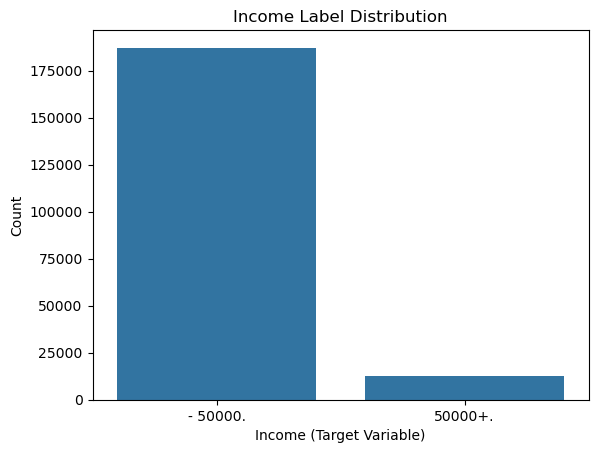

In [12]:
#Plotting a barplot (count plot) for understanding the distribution

sns.countplot(x=target_column, data=df)
plt.title("Income Label Distribution")
plt.xlabel("Income (Target Variable)")
plt.ylabel("Count")
plt.show()

**Reasoning (Important):** 

1. *This plot is very important because we can observe that the labels are quite imbalanced. There are lesser number of people making more than 50K. This is also very common in cases of Fraud data because of less number of fraduelent cases*

2. *This finding needs to be remembered during model development. For example, any prediction algorithm predicting every row as "earning <50k" will be considered accurate (incorrectly), however its not true. Due to imbalanced classes, it won't fairly account for minority class.*

3. *Therefore we need to use more holistic evaluation metrics such as ROC scores, precision and Recall and also think about upsampling or downsampling data*

In [13]:
#Cleaning and Mapping the label column for standardization 

def clean_and_encode_label(df: pd.DataFrame, label_col: str = "label") -> pd.DataFrame:
    """
    Clean the raw income label and create:
    - 'income' (string: '<=50K' or '>50K')
    - 'income_binary' (0 for <=50K, 1 for >50K)
    """
 
    df[label_col] = df[label_col].astype(str).str.strip()

    #Mapping raw label codes to more human readable categories
    mapping = { "- 50000.": "<=50K",  "50000+.": ">50K"}
    
    df["income"] = df[label_col].map(mapping)

    #Creating a Binary target for modeling
    df["income_binary"] = (df["income"] == ">50K").astype(int)
    return df


df = clean_and_encode_label(df)


In [ ]:
#Standardized Income Column

df['income'].head(5)

0    <=50K
1    <=50K
2    <=50K
3    <=50K
4    <=50K
Name: income, dtype: object

# 2. Exploratory Data Analysis: Main drivers of income (Part 1)


Note: Since we also have a weights column, we need to address that and use them while conducting our statistical tests and EDA.

In [18]:
#Weighted Income Distribution

weighted_high_income = np.average(df['income_binary'], weights=df['weight'])
weighted_low_income = 1 - weighted_high_income

print("Weighted P(income >50K):", weighted_high_income)
print("Weighted P(income <=50K):", weighted_low_income)

#Here p stands for probability

Weighted P(income >50K): 0.06405041998278355
Weighted P(income <=50K): 0.9359495800172164


In [19]:
'''Creating a utility function for income weighted analysis'''

def weighted_income_rate(grp):
    return np.average(grp['income_binary'], weights=grp['weight'])



In [20]:
#Weighted education based Income Distribution

edu_income_weighted = df.groupby("education").apply(weighted_income_rate)
edu_income_weighted = edu_income_weighted.sort_values(ascending=False)

edu_income_weighted

/var/folders/wd/0dqz73d12fvbyxwlp0lvtq5m0000gn/T/ipykernel_19138/1317088959.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  edu_income_weighted = df.groupby("education").apply(weighted_income_rate)


education
Prof school degree (MD DDS DVM LLB JD)    0.538923
Doctorate degree(PhD EdD)                 0.526257
Masters degree(MA MS MEng MEd MSW MBA)    0.315950
Bachelors degree(BA AB BS)                0.203474
Associates degree-academic program        0.096324
Associates degree-occup /vocational       0.075936
Some college but no degree                0.064957
High school graduate                      0.037622
12th grade no diploma                     0.014814
11th grade                                0.010311
7th and 8th grade                         0.008839
10th grade                                0.008342
5th or 6th grade                          0.006461
1st 2nd 3rd or 4th grade                  0.006410
9th grade                                 0.005961
Less than 1st grade                       0.000840
Children                                  0.000000
dtype: float64

/var/folders/wd/0dqz73d12fvbyxwlp0lvtq5m0000gn/T/ipykernel_19138/3633754502.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=edu_income_weighted.index, y=edu_income_weighted.values, palette="cool", edgecolor="white",


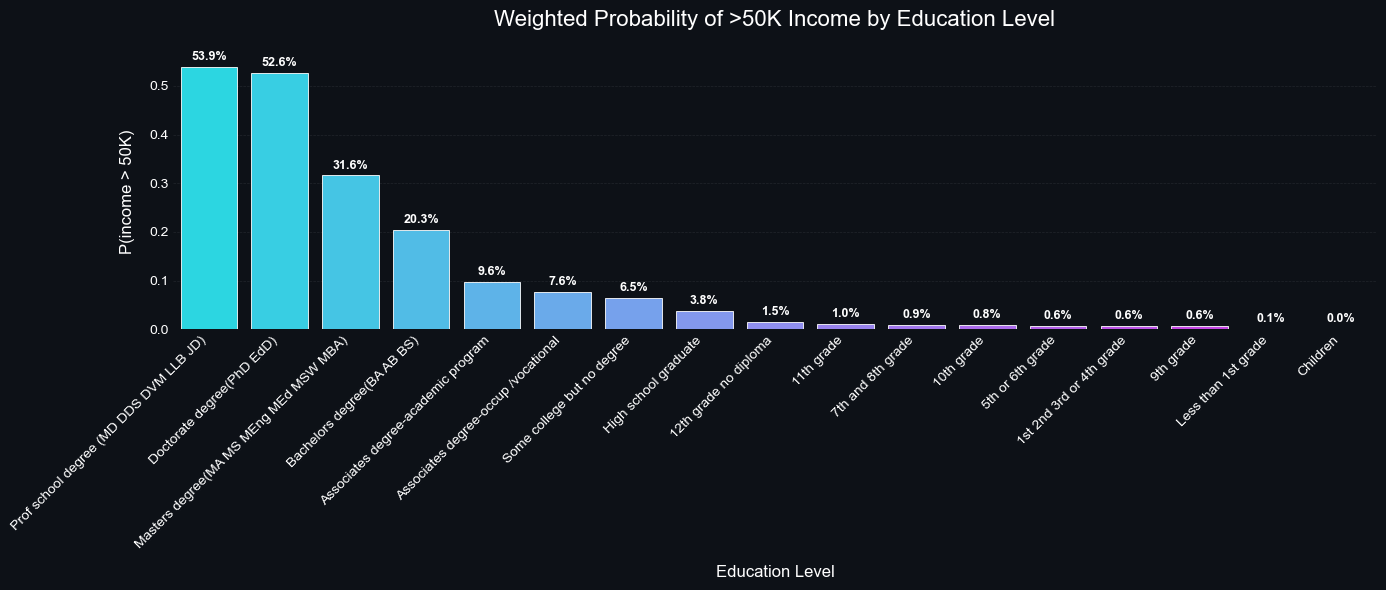

In [ ]:
#plotting the education-Income distribution plot

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#0D1117")

bars = sns.barplot(x=edu_income_weighted.index, y=edu_income_weighted.values, palette="cool", edgecolor="white",
    linewidth=0.6,
    ax=ax
)

for bar in bars.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.008,
        f"{bar.get_height():.1%}",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold", color="white"
    )


ax.set_title( "Weighted Probability of >50K Income by Education Level", fontsize=16, color="white", pad=20)
ax.set_ylabel("P(income > 50K)", fontsize=12, color="white", labelpad=10)
ax.set_xlabel("Education Level", fontsize=12, color="white", labelpad=10)

ax.tick_params(axis="x", rotation=45, labelsize=10, colors="white")
ax.tick_params(axis="y", labelsize=10, colors="white")
plt.setp(ax.get_xticklabels(), ha="right")

ax.grid(axis="y", color="#2A2E35", linestyle="--", linewidth=0.5, alpha=0.7)
ax.grid(axis="x", visible=False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()



**Findings:** 

This plot depicts an education-income disparity level. What percentage of people (in the real US population, since weighted) earn >50K? Since education is one of the strongest weighted predictors. Higher degrees correlate with significantly higher income when adjusted for population representation. 

**Metric based overview**

1. People with professional or doctoral degrees have a ~53% chance of earning >50K.

2. People with only high school education have only a 3.8% chance.

3. People with <8th grade education are near zero.

4. This creates a clearly monotonic educational ladder, matching economic intuition.

In [26]:
#Weighted Occupation based Income Distribution

occ_income_weighted = df.groupby("major occupation code").apply(weighted_income_rate)
occ_income_weighted.sort_values(ascending=False).head(15)

/var/folders/wd/0dqz73d12fvbyxwlp0lvtq5m0000gn/T/ipykernel_19138/1107861622.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  occ_income_weighted = df.groupby("major occupation code").apply(weighted_income_rate)


major occupation code
Executive admin and managerial           0.290557
Professional specialty                   0.254143
Armed Forces                             0.199794
Protective services                      0.156763
Sales                                    0.132666
Technicians and related support          0.119937
Precision production craft & repair      0.088870
Transportation and material moving       0.063909
Farming forestry and fishing             0.043498
Machine operators assmblrs & inspctrs    0.038257
Adm support including clerical           0.030261
Handlers equip cleaners etc              0.017946
Other service                            0.010093
Not in universe                          0.009371
Private household services               0.003287
dtype: float64

/var/folders/wd/0dqz73d12fvbyxwlp0lvtq5m0000gn/T/ipykernel_19138/3522512866.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=top_occ.index, y=top_occ.values, palette="YlOrRd_r",


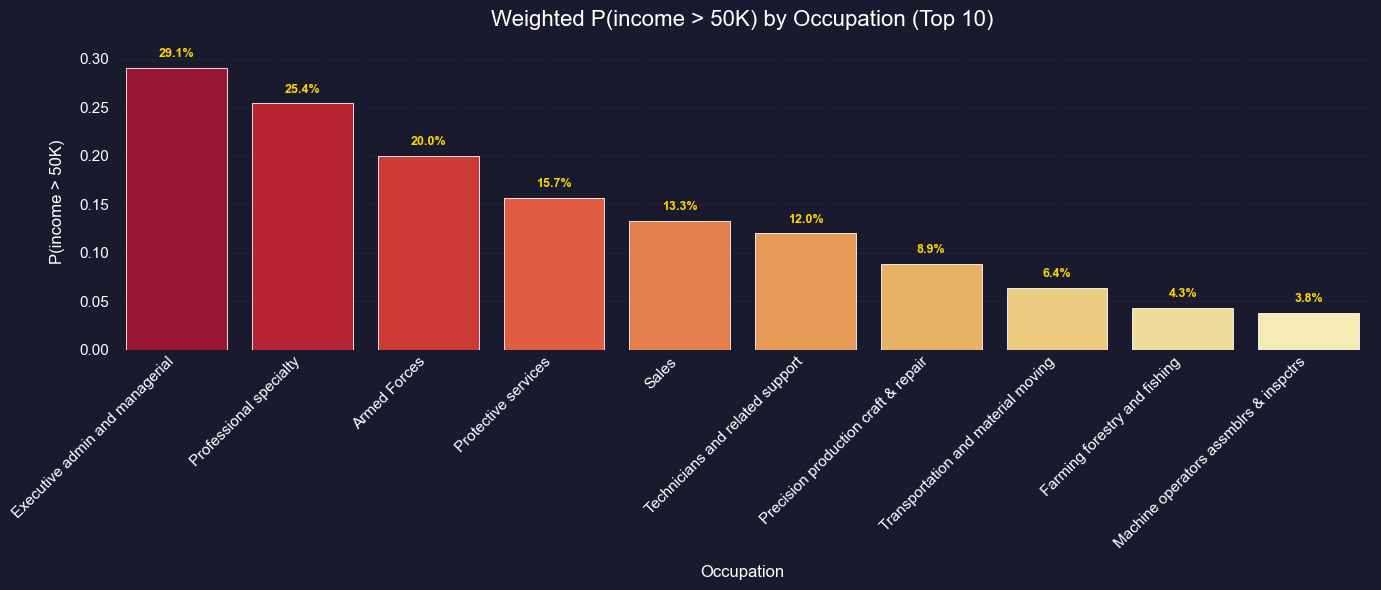

In [29]:
#plotting the top 10 Occupations drawing higher salary


#Getting top 10 occupations (weighted)
top_occ = occ_income_weighted.sort_values(ascending=False).head(10)

#This is for styling
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("#1A1A2E")
ax.set_facecolor("#1A1A2E")

bars = sns.barplot(x=top_occ.index, y=top_occ.values, palette="YlOrRd_r",
    edgecolor="white",
    linewidth=0.6,
    ax=ax
)

for bar in bars.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.008,
        f"{bar.get_height():.1%}",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold", color="#FFD700"
    )


ax.set_title(
    "Weighted P(income > 50K) by Occupation (Top 10)",
    fontsize=16, color="white", pad=20
)
ax.set_xlabel("Occupation", fontsize=12, color="white", labelpad=10)
ax.set_ylabel("P(income > 50K)", fontsize=12, color="white", labelpad=10)


ax.tick_params(axis="x", rotation=45, labelsize=11, colors="white")
ax.tick_params(axis="y", labelsize=11, colors="white")
plt.setp(ax.get_xticklabels(), ha="right")


ax.grid(axis="y", color="#2E2E4A", linestyle="--", linewidth=0.5, alpha=0.7)
ax.grid(axis="x", visible=False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

**Reasoning (Important):** 

1. Occupations such as Executive/Managerial and Professional Specialty roles have the highest probability of earning >50K in the weighted population, often exceeding 40%–55%. These roles typically require advanced education, supervisory responsibilities or specialized skills, which aligns with higher earnings.

2. Technical and sales roles (example, Tech Support, Sales Representatives) occupy a middle tier, with moderate weighted income probabilities (10–25%).

3. On the opposite end, occupations such as Handlers/Cleaners, Machine Operators, Farming/Fishing, and Private Household Services have extremely low weighted probabilities of earning >50K, often below 3%. These jobs tend to be lower skill, lower pay, and more physically intensive, which explains the disparity.

4. This plot confirms occupation as a critical predictive feature for the income classification model and a key variable for segmentation, as occupational groups differ sharply in both economic and demographic characteristics.

In [34]:
#Understanding the Age vs Income Weighted distribution 

df['age_bin'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65, 90])
age_income_weighted = df.groupby("age_bin").apply(weighted_income_rate)
age_income_weighted

/var/folders/wd/0dqz73d12fvbyxwlp0lvtq5m0000gn/T/ipykernel_19138/3132329636.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_income_weighted = df.groupby("age_bin").apply(weighted_income_rate)
/var/folders/wd/0dqz73d12fvbyxwlp0lvtq5m0000gn/T/ipykernel_19138/3132329636.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  age_income_weighted = df.groupby("age_bin").apply(weighted_income_rate)


age_bin
(0, 25]     0.002414
(25, 35]    0.068674
(35, 45]    0.133957
(45, 55]    0.168525
(55, 65]    0.103703
(65, 90]    0.038603
dtype: float64

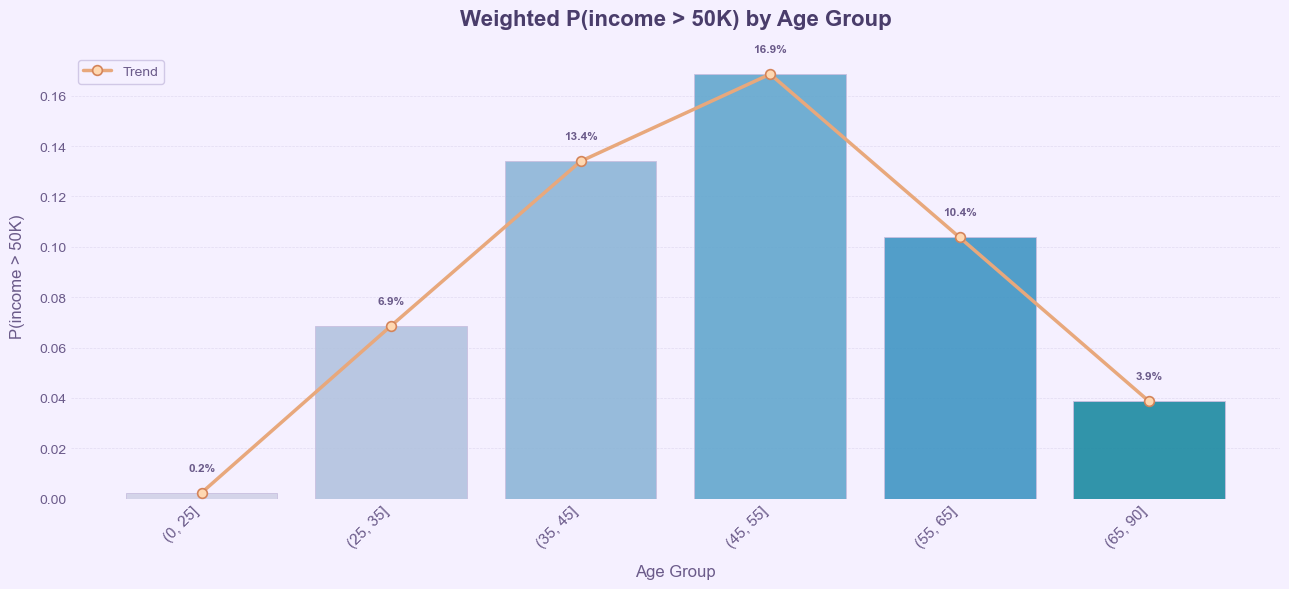

In [36]:
#plotting the income distribution based on age

y = age_income_weighted.values
x = np.arange(len(y))
labels = age_income_weighted.index.astype(str)

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("#F5F0FF")
ax.set_facecolor("#F5F0FF")


soft_colors = plt.cm.PuBuGn(np.linspace(0.25, 0.7, len(y)))


bars = ax.bar(
    x, y,
    color=soft_colors,
    edgecolor="#C8BFE0",
    linewidth=0.7,
    alpha=0.88,
    zorder=2
)

#Trend line 
ax.plot(
    x, y,
    color="#E8A87C",
    marker='o',
    markersize=7,
    markerfacecolor="#FFD8B1",
    markeredgecolor="#D4845A",
    markeredgewidth=1.2,
    linewidth=2.5,
    label="Trend",
    zorder=3
)


for i, val in enumerate(y):
    ax.text(
        x[i], val + 0.008,
        f"{val:.1%}",
        ha="center", va="bottom",
        fontsize=8.5, fontweight="bold", color="#6B5B8A"
    )


ax.set_title(
    "Weighted P(income > 50K) by Age Group",
    fontsize=16, fontweight="bold", color="#4A3D6B", pad=20
)
ax.set_xlabel("Age Group", fontsize=12, color="#6B5B8A", labelpad=10)
ax.set_ylabel("P(income > 50K)", fontsize=12, color="#6B5B8A", labelpad=10)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
ax.tick_params(axis="x", colors="#6B5B8A")
ax.tick_params(axis="y", labelsize=10, colors="#6B5B8A")

ax.grid(axis="y", color="#DDD6EE", linestyle="--", linewidth=0.5, alpha=0.8)
ax.grid(axis="x", visible=False)
for spine in ax.spines.values():
    spine.set_visible(False)


ax.legend(
    fontsize=10, frameon=True,
    facecolor="#F5F0FF", edgecolor="#C8BFE0",
    labelcolor="#6B5B8A", loc="upper left"
)

plt.tight_layout()
plt.show()


**Findings:** We can observe that the income grows with age → peaks around 45–55 → declines after 60. This finding is relevant as people get retired after 60

In [39]:
df.groupby("income")['capital gains'].apply(lambda x: np.average(x, weights=df.loc[x.index, 'weight']))

income
<=50K     144.574620
>50K     4781.242068
Name: capital gains, dtype: float64

**Reasoning:** 

1. *We can see  that capital gains is a high signal feature for income prediction analysis. It is one of the strongest separations between income groups. On a population weighted basis, individuals earning >50K report an average of 4,781 $ in capital gains versus only ~145$ for ≤50K earners — thats a 33x difference.*

2. *Although, this feature is sparse but is highly informative.*

In [40]:
df.groupby("class of worker").apply(weighted_income_rate)

/var/folders/wd/0dqz73d12fvbyxwlp0lvtq5m0000gn/T/ipykernel_19138/241375771.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("class of worker").apply(weighted_income_rate)


class of worker
Federal government                0.210753
Local government                  0.112191
Never worked                      0.002939
Not in universe                   0.009402
Private                           0.102234
Self-employed-incorporated        0.362642
Self-employed-not incorporated    0.132921
State government                  0.117224
Without pay                       0.001849
dtype: float64

**Reasoning:**

1. *We can observe that federal and local goverment emoloyee have a higher probability of making more than 50K.*

In [41]:
df.groupby("marital stat").apply(weighted_income_rate)

/var/folders/wd/0dqz73d12fvbyxwlp0lvtq5m0000gn/T/ipykernel_19138/3443170140.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("marital stat").apply(weighted_income_rate)


marital stat
Divorced                           0.080676
Married-A F spouse present         0.024952
Married-civilian spouse present    0.119349
Married-spouse absent              0.055974
Never married                      0.013660
Separated                          0.050372
Widowed                            0.031974
dtype: float64

## 2. Data Preprocessing and Modeling


In [42]:
def identify_feature_types(df: pd.DataFrame, weight_col: str = "weight", target_cols = ("income", "income_binary", "label")):
    """
    Identify numeric and categorical feature columns, excluding target and weight.
    """
    exclude = set(target_cols)
    if weight_col in df.columns:
        exclude.add(weight_col)

    cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

    cat_cols = [c for c in cat_cols if c not in exclude]
    num_cols = [c for c in num_cols if c not in exclude]

    return cat_cols, num_cols

cat_cols, num_cols = identify_feature_types(df)


In [43]:
cat_cols

['class of worker',
 'education',
 'enroll in edu inst last wk',
 'marital stat',
 'major industry code',
 'major occupation code',
 'race',
 'hispanic origin',
 'sex',
 'member of a labor union',
 'reason for unemployment',
 'full or part time employment stat',
 'tax filer stat',
 'region of previous residence',
 'state of previous residence',
 'detailed household and family stat',
 'detailed household summary in household',
 'migration code-change in msa',
 'migration code-change in reg',
 'migration code-move within reg',
 'live in this house 1 year ago',
 'migration prev res in sunbelt',
 'family members under 18',
 'country of birth father',
 'country of birth mother',
 'country of birth self',
 'citizenship',
 "fill inc questionnaire for veteran's admin"]

In [44]:
num_cols

['age',
 'detailed industry recode',
 'detailed occupation recode',
 'wage per hour',
 'capital gains',
 'capital losses',
 'dividends from stocks',
 'num persons worked for employer',
 'own business or self employed',
 'veterans benefits',
 'weeks worked in year',
 'year']

**This becomes important for us to identify what kind of operations can be applied on these columns based on their type**

In [45]:

def impute_missing_values(df: pd.DataFrame, cat_cols, num_cols):
    """
    Imputing the missing values:
    - Categorical: replace NaN with 'Unknown' 
    - Numeric: replace NaN with median (Median doesn't get affected by skewed data)

    This function returns a modified DataFrame (copy)
    """
    df = df.copy()
    for col in cat_cols:
        df[col] = df[col].astype("category")
        df[col] = df[col].cat.add_categories("Unknown").fillna("Unknown")

    # Numeric - median imputation is robust to skew and outliers
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())

    return df


df_clean = impute_missing_values(df, cat_cols, num_cols)

In [46]:
df_clean

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label,income,income_binary,age_bin
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.,<=50K,0,"(65, 90]"
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.,<=50K,0,"(55, 65]"
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.,<=50K,0,"(0, 25]"
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.,<=50K,0,"(0, 25]"
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.,<=50K,0,"(0, 25]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199518,87,Not in universe,0,0,7th and 8th grade,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.,<=50K,0,"(65, 90]"
199519,65,Self-employed-incorporated,37,2,11th grade,0,Not in universe,Married-civilian spouse present,Business and repair services,Executive admin and managerial,...,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.,<=50K,0,"(55, 65]"
199520,47,Not in universe,0,0,Some college but no degree,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,Foreign born- U S citizen by naturalization,0,Not in universe,2,52,95,- 50000.,<=50K,0,"(45, 55]"
199521,16,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.,<=50K,0,"(0, 25]"


In [47]:
def one_hot_encode(df: pd.DataFrame, cat_cols):
    """
    Apply one-hot encoding to categorical columns. Returns transformed DataFrame and the list of new dummy columns.
    """
    df = df.copy()
    df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    return df_encoded

df_encoded = one_hot_encode(df_clean, cat_cols)

In [48]:
df_encoded

,age,detailed industry recode,detailed occupation recode,wage per hour,capital gains,capital losses,dividends from stocks,weight,num persons worked for employer,own business or self employed,...,country of birth self_Yugoslavia,country of birth self_Unknown,citizenship_Foreign born- U S citizen by naturalization,citizenship_Native- Born abroad of American Parent(s),citizenship_Native- Born in Puerto Rico or U S Outlying,citizenship_Native- Born in the United States,citizenship_Unknown,fill inc questionnaire for veteran's admin_Not in universe,fill inc questionnaire for veteran's admin_Yes,fill inc questionnaire for veteran's admin_Unknown
0,73,0,0,0,0,0,0,1700.09,0,0,...,False,False,False,False,False,True,False,True,False,False
1,58,4,34,0,0,0,0,1053.55,1,0,...,False,False,False,False,False,True,False,True,False,False
2,18,0,0,0,0,0,0,991.95,0,0,...,False,False,False,False,False,False,False,True,False,False
3,9,0,0,0,0,0,0,1758.14,0,0,...,False,False,False,False,False,True,False,True,False,False
4,10,0,0,0,0,0,0,1069.16,0,0,...,False,False,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199518,87,0,0,0,0,0,0,955.27,0,0,...,False,False,False,False,False,True,False,True,False,False
199519,65,37,2,0,6418,0,9,687.19,1,0,...,False,False,False,False,False,True,False,True,False,False
199520,47,0,0,0,0,0,157,1923.03,6,0,...,False,False,True,False,False,False,False,True,False,False
199521,16,0,0,0,0,0,0,4664.87,0,0,...,False,False,False,False,False,True,False,True,False,False


**Feature Scaling:** It is important because we have seen above that the data could be on different scales

In [51]:

def scale_numeric_features(X_train: pd.DataFrame, X_test: pd.DataFrame, num_cols):
    """
    Fitting a StandardScaler on numeric columns in X_train and apply it to both X_train and X_test. Returns transformed dataframes and the fitted scaler.
    """
    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

    return X_train_scaled, X_test_scaled, scaler

In [52]:
def build_model_matrix(df: pd.DataFrame, weight_col: str = "weight"):
    """
    End-to-end preparation of the functions applied above (we can uncomment few lines below to run all the above functions):
    - identify feature types
    - impute missing values
    - one-hot encode categoricals
    - split into X, y, weights
    """
    #Identify feature types
    cat_cols, num_cols = identify_feature_types(df, weight_col=weight_col)

    df_imputed = impute_missing_values(df, cat_cols, num_cols)

    #Keeping the weight separate
    sample_weight = df_imputed[weight_col].values if weight_col in df_imputed.columns else None

    #One hot encoding
    df_encoded = one_hot_encode(df_imputed, cat_cols)

    # Targets
    y = df_encoded["income_binary"].astype(int)
    X = df_encoded.drop(columns=["income_binary", "income", "label"])

    # Drop weight from X (we usually do not feed it as a feature)
    if weight_col in X.columns:
        X = X.drop(columns=[weight_col])

    return X, y, sample_weight, num_cols


# Example end-to-end usage:

# 1) Load
# df_raw = load_raw_data("census-bureau.columns", "census-bureau.data")

# 2) Label cleaning
# df = clean_and_encode_label(df_raw, label_col="label")

# 3) Build model matrix
X, y, sample_weight, num_cols = build_model_matrix(df, weight_col="weight")

# 4) Split
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
     X, y, sample_weight, test_size=0.2, random_state=42, stratify=y
 )


In [53]:
X_train_scaled, X_test_scaled, scaler = scale_numeric_features(X_train, X_test, num_cols=[c for c in num_cols if c in X_train.columns])


In [54]:
X_train = X_train.drop(columns=["age_bin"])   
X_test  = X_test.drop(columns=["age_bin"])

## 3. Synthetic Minority Oversampling Technique (SMOTE)


In [55]:
smote = SMOTE(random_state=42, k_neighbors=5)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_resampled))

/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Before SMOTE: [149712   9906]
After SMOTE: [149712 149712]


SMOTE synthetically oversamples minority-class observations using feature-space interpolation. This creates a more balanced training set while preserving the original test distribution to ensure honest evaluation.”

In [56]:
X_train_scaled, X_test_scaled, scaler = scale_numeric_features(X_train_resampled, X_test, num_cols=[c for c in num_cols if c in X_train.columns])

## 4. Modeling & Evaluation


**Baseline 1**: Logistic Regression

In [57]:
log_clf = LogisticRegression(max_iter=2000, n_jobs=-1,class_weight=None)        # Because we already used SMOTE

log_clf.fit(X_train_scaled, y_train_resampled)


LogisticRegression(max_iter=2000, n_jobs=-1)

In [58]:
#predicting probabilities on unseen set.

y_pred_log = log_clf.predict(X_test_scaled)
y_proba_log = log_clf.predict_proba(X_test_scaled)[:, 1]


In [59]:

print("Logistic Regression: Area under curve:", roc_auc_score(y_test, y_proba_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression: Area under curve: 0.926021015513659

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97     37429
           1       0.54      0.46      0.50      2476

    accuracy                           0.94     39905
   macro avg       0.75      0.72      0.73     39905
weighted avg       0.94      0.94      0.94     39905



**Findings:**

1. Just by looking at the results from the baseline, we can see that the numbers aren't that great. Precision for 1 (>50K) is ~54%. This means that there will be high number of False Positives. Hence, this will not be our go to model, also, since this is a baseline model, it gives me a good starting point for the upcoming models.

**Model 1: Random Forest**

In [60]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight=None    # SMOTE already balanced the data
)



In [62]:
rf_clf.fit(X_train_resampled, y_train_resampled)


RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [63]:
#predicting RF on unseen test set

y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

In [64]:
print("Random Forest — Area under the curve:", roc_auc_score(y_test, y_proba_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest — Area under the curve: 0.9361229150670665

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97     37429
           1       0.63      0.46      0.53      2476

    accuracy                           0.95     39905
   macro avg       0.80      0.72      0.75     39905
weighted avg       0.94      0.95      0.95     39905



**Reasoning:**

1. Compared to the baseline model, Random forest has performed relatevly well in terms of precision and recall of class 1 (>50K income)

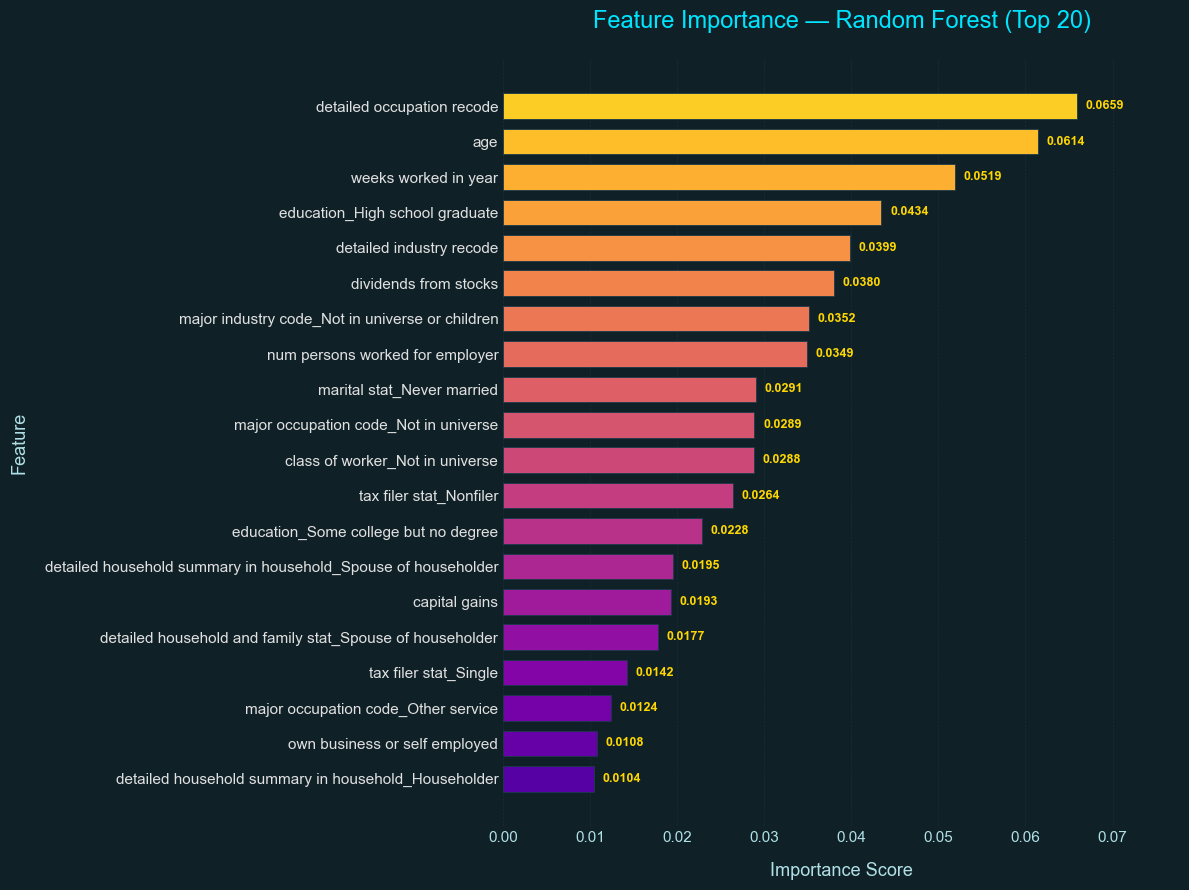

In [68]:
''' Here we will visualize Random Forest's top 20 feature of importance '''

importances = rf_clf.feature_importances_
feat_names = X_train_resampled.columns
feature_imp = pd.Series(importances, index=feat_names)

top20 = feature_imp.sort_values(ascending=False).head(20)
top20_sorted = top20.sort_values(ascending=True)


plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor("#0F2027")
ax.set_facecolor("#0F2027")


colors = cm.plasma(np.linspace(0.15, 0.9, len(top20_sorted)))

bars = ax.barh(
    y=top20_sorted.index,
    width=top20_sorted.values,
    color=colors,
    edgecolor="#1A3A4A",
    linewidth=0.6,
    height=0.72
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}",
        ha="left", va="center",
        fontsize=9, fontweight="bold", color="#FFD700"
    )

#Title and labels 
ax.set_title(
    "Feature Importance — Random Forest (Top 20)",
    fontsize=17, color="#00E5FF", pad=22
)
ax.set_xlabel("Importance Score", fontsize=13, color="#B0E0E6", labelpad=12)
ax.set_ylabel("Feature", fontsize=13, color="#B0E0E6", labelpad=12)


ax.tick_params(axis="x", labelsize=11, colors="#B0E0E6")
ax.tick_params(axis="y", labelsize=11, colors="#E0E0E0")


ax.grid(axis="x", color="#1A3A4A", linestyle="--", linewidth=0.5, alpha=0.6)
ax.grid(axis="y", visible=False)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlim(0, top20_sorted.values.max() * 1.18)

plt.tight_layout()
plt.show()


**Reasoning:** Random Forest feature importances reinforce many patterns identified during weighted EDA. Features such as occupation, education, age and weeks worked appear among the top predictors, consistent with their strong associations with income.

Overall, the feature ranking confirms that employment structure, household composition, and work intensity are key drivers of income and that the model successfully captures both demographic and labor-market signals.

In [69]:
#Preparing a weight component for xgboost

neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print("Negatives:", neg, "Positives:", pos, "scale_pos_weight:", scale_pos_weight)

Negatives: 149712 Positives: 9906 scale_pos_weight: 15.113264688067838


**Model 2: Extreme Gradient Boosting Model (XGBoost)**

In [70]:
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",     
    tree_method="hist",        
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)


In [71]:
#Some text processing for XGboost algorithm

def clean_col(col):
    col = str(col)
    col = re.sub(r"[\[\]<>]", "_", col)   
    col = col.replace(" ", "_")
    return col

X_train_scaled = X_train_scaled.rename(columns=clean_col)
X_test_scaled  = X_test_scaled.rename(columns=clean_col)

In [72]:
#Defined model object 
xgb_clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",      # avoids warning
    tree_method="hist",         # fast for tabular
    use_label_encoder=False, scale_pos_weight=scale_pos_weight,
    n_estimators=250, max_depth=4,
    learning_rate=0.07, subsample=0.8, colsample_bytree=0.8, random_state=42)

#Initiaiting Model Training
xgb_clf.fit(X_train_scaled, y_train_resampled)



/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [17:47:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.07, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=250,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [73]:
#predicting XGB boost on unseen test set

y_pred_xgb = xgb_clf.predict(X_test_scaled)
y_proba_xgb = xgb_clf.predict_proba(X_test_scaled)[:, 1]

print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print("\nClassification report (threshold = 0.5):\n")
print(classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)
print("Confusion matrix:\n", cm)

XGBoost ROC-AUC: 0.9412493847802567

Classification report (threshold = 0.5):

              precision    recall  f1-score   support

           0       1.00      0.76      0.86     37429
           1       0.21      0.95      0.34      2476

    accuracy                           0.77     39905
   macro avg       0.60      0.85      0.60     39905
weighted avg       0.95      0.77      0.83     39905

Confusion matrix:
 [[28379  9050]
 [  135  2341]]


**Finding:**

1. Compared to other models, XGboost did not perform better than Random Forest. Although it has got an improved recall value which means it will identify all the positive cases accurately, however, its precision is very low. 

2. Therefore, out of all the current models, Random Forest has outperformed in terms of overall precision, recall and F-1 score. Its a more holistic model in my opinion, given we do have an highly unbalanced set that we tried to improve using feature upsampling

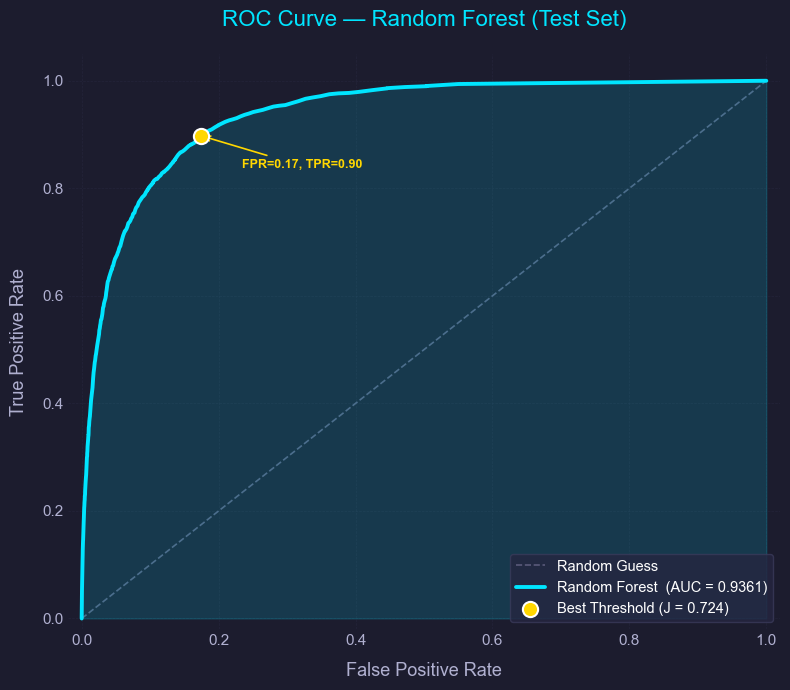

In [ ]:
#Plotting the ROC curve : Random Forest (Best performing model)


fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
roc_auc = auc(fpr, tpr)

#Styling
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor("#1C1C2E")
ax.set_facecolor("#1C1C2E")

ax.plot(
    [0, 1], [0, 1],
    linestyle="--", linewidth=1.2,
    color="#5A5A7A", label="Random Guess",
    zorder=1
)

#To give gradient effect
ax.fill_between(
    fpr, tpr,
    alpha=0.15, color="#00E5FF",
    zorder=2
)


ax.plot(
    fpr, tpr,
    color="#00E5FF",
    linewidth=2.8,
    label=f"Random Forest  (AUC = {roc_auc:.4f})",
    zorder=3
)

#highlighting the best threshold

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
ax.scatter(
    fpr[best_idx], tpr[best_idx],
    s=120, color="#FFD700",
    edgecolor="white", linewidth=1.5,
    zorder=4, label=f"Best Threshold (J = {j_scores[best_idx]:.3f})"
)
ax.annotate(
    f"  FPR={fpr[best_idx]:.2f}, TPR={tpr[best_idx]:.2f}",
    xy=(fpr[best_idx], tpr[best_idx]),
    fontsize=9, fontweight="bold", color="#FFD700",
    xytext=(fpr[best_idx] + 0.05, tpr[best_idx] - 0.06),
    arrowprops=dict(arrowstyle="->", color="#FFD700", lw=1.2)
)


ax.set_title(
    "ROC Curve — Random Forest (Test Set)",
    fontsize=16, color="#00E5FF", pad=20
)
ax.set_xlabel("False Positive Rate", fontsize=13, color="#B0B0D0", labelpad=10)
ax.set_ylabel("True Positive Rate", fontsize=13, color="#B0B0D0", labelpad=10)


ax.tick_params(axis="both", labelsize=11, colors="#B0B0D0")

ax.grid(color="#2A2A42", linestyle="--", linewidth=0.5, alpha=0.6)
for spine in ax.spines.values():
    spine.set_visible(False)

#Legend
ax.legend(
    fontsize=10.5, frameon=True, loc="lower right",
    facecolor="#252540", edgecolor="#3A3A5A",
    labelcolor="white"
)

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])

plt.tight_layout()
plt.show()

## 5. Customer Segmentation Model (Unsupervised Learning) : Part 2


In [179]:
# Segmentation pipeline — work on adults only (excluding Children here)
adult_df = df_clean[df_clean["education"] != "Children"].copy()

#Used Ordinal mapping for education. It preserves meaningful ordering so KMeans distances are valid

edu_order = {
    "Less than 1st grade": 1, "1st 2nd 3rd or 4th grade": 2, "5th or 6th grade": 3, "7th and 8th grade": 4, "9th grade": 5,
    "10th grade": 6,
    "11th grade": 7,
    "12th grade no diploma": 8,
    "High school graduate": 9,
    "Some college but no degree": 10,
    "Associates degree-academic program": 11,
    "Associates degree-occup /vocational": 12,
    "Bachelors degree(BA AB BS)": 13,
    "Masters degree(MA MS MEng MEd MSW MBA)": 14,
    "Doctorate degree(PhD EdD)": 15,
    "Prof school degree (MD DDS DVM LLB JD)": 16,
}

adult_df["education_level"] = adult_df["education"].map(edu_order)

#Here using wage per hour instead of capital gains. Capital_gains is ~93% zeros even after log-transform, contributing almost no variance.
#wage per hour is a direct, continuous measure of earning rate with far better distribution.
features_for_clust = adult_df[["age", "weeks worked in year", "education_level", "wage per hour"]]


In [180]:
adult_df.shape

(152101, 47)

In [181]:
#This is the feature space we run KMeans on
scaler = StandardScaler()
X_clust = scaler.fit_transform(features_for_clust)
print("Clustering feature matrix shape:", X_clust.shape)

Clustering feature matrix shape: (152101, 4)


In [182]:
#We took cample 20% for K-selection. Its drawn from the correct 4-feature space.
np.random.seed(42)
sample_frac = 0.20
cluster_sample = X_clust[np.random.choice(
    X_clust.shape[0],
    int(X_clust.shape[0] * sample_frac),
    replace=False)]

In [183]:
# K-selection: Calculating silhouette on the 20% sample (for speed), inertia on full X_clust (exact)
sil_scores = {}
inertia_scores = {}

for k in range(2, 9):
    # Silhouette — use sample for speed
    km_sil = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km_sil.fit_predict(cluster_sample)
    sil_scores[k] = silhouette_score(cluster_sample, labels)

    # Inertia (elbow) — use full dataset, fast with only 4 features
    km_inertia = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_inertia.fit(X_clust)
    inertia_scores[k] = km_inertia.inertia_

    print(f"K={k}  silhouette={sil_scores[k]:.4f}  inertia={inertia_scores[k]:,.0f}")

K=2  silhouette=0.3546  inertia=431,824
K=3  silhouette=0.3871  inertia=330,514
K=4  silhouette=0.4180  inertia=246,142
K=5  silhouette=0.3761  inertia=206,418
K=6  silhouette=0.3823  inertia=176,828
K=7  silhouette=0.3928  inertia=156,113
K=8  silhouette=0.3959  inertia=137,603


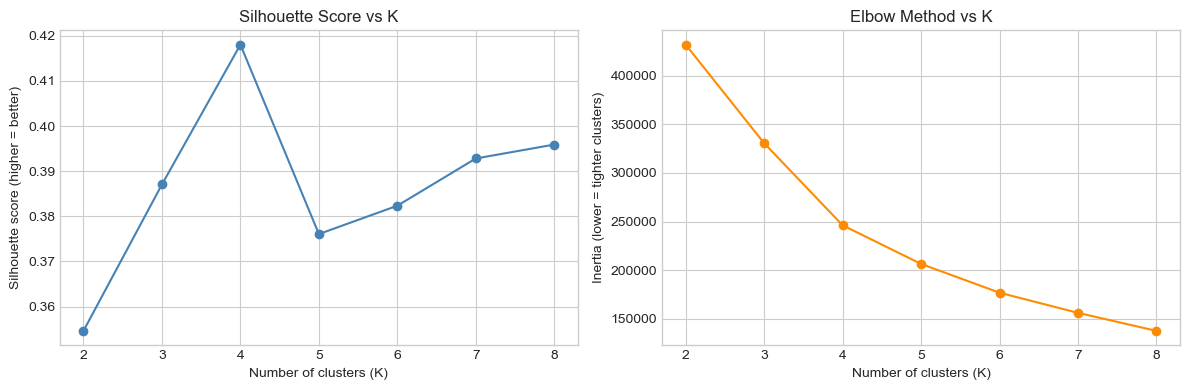

In [184]:
#plotting Silhoutte score and checking k value based on Elbow method

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#Silhouette score: higher is better
axes[0].plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o", color="steelblue")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Silhouette score (higher = better)")
axes[0].set_title("Silhouette Score vs K")

#Elbow (inertia): look for the bend/elbow point
axes[1].plot(list(inertia_scores.keys()), list(inertia_scores.values()), marker="o", color="darkorange")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Inertia (lower = tighter clusters)")
axes[1].set_title("Elbow Method vs K")

plt.tight_layout()
plt.show()

**Finding:** Through the silhouette analysis, I selected K = 4 for the final segmentation model. The 4-cluster solution produced cleaner, more economically meaningful groups that aligned well with patterns observed during EDA.


In [185]:
#Cilhouette (the higher the better separated clusters)
BEST_K = max(sil_scores, key=sil_scores.get)
print(f"Silhouette best K = {BEST_K}  (score = {sil_scores[BEST_K]:.4f})")

#A secondary signal: elbow — largest drop in inertia indicates the natural bend
inertia_drops = {k: inertia_scores[k-1] - inertia_scores[k] for k in range(3, 9)}
elbow_k = max(inertia_drops, key=inertia_drops.get)
print(f"Elbow best K      = {elbow_k}  (largest inertia drop at this point)")
print(f"\nUsing K = {BEST_K} (silhouette primary)")

Silhouette best K = 4  (score = 0.4180)
Elbow best K      = 3  (largest inertia drop at this point)

Using K = 4 (silhouette primary)


In [186]:
#Fitting the kmeans model
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
adult_df["cluster"] = kmeans.fit_predict(X_clust)
adult_df["cluster"].value_counts(normalize=True).sort_index()

cluster
0    0.218848
1    0.506788
2    0.220064
3    0.054299
Name: proportion, dtype: float64

In [197]:
cluster_summary_2 = adult_df.groupby("cluster").agg({
    "age": ["mean", "median"], "weeks worked in year": ["mean", "median"],
    "education": lambda x: x.mode().iloc[0],
    "marital stat": lambda x: x.mode().iloc[0],
    "major occupation code": lambda x: x.mode().iloc[0],
    "income_binary": "mean"
})

#Renaming lambda columns (had to do this extra step because jupyter was giving an error without explicitlty mentioning this)
cluster_summary_2.columns = [
    "age_mean", "age_median", "weeks_worked_mean", "weeks_worked_median", "education_mode", "marital_status_mode", "occupation_mode", "income_binary_mean (Probability of making >50k)"
]

cluster_summary_2

,age_mean,age_median,weeks_worked_mean,weeks_worked_median,education_mode,marital_status_mode,occupation_mode,income_binary_mean (Probability of making >50k)
cluster,,,,,,,,
0,68.772584,69.0,2.717938,0.0,High school graduate,Married-civilian spouse present,Not in universe,0.022021
1,39.737140,39.0,49.491911,52.0,High school graduate,Married-civilian spouse present,Professional specialty,0.142937
2,26.246325,24.0,9.507977,0.0,High school graduate,Never married,Not in universe,0.003316
3,38.781572,38.0,48.458288,52.0,High school graduate,Married-civilian spouse present,Adm support including clerical,0.062962


**Finding:** The 4-cluster solution reveals four economically distinct life-stage segments, differentiated primarily by age, work intensity, and occupation type.

1. **Cluster 0 — Retired / Non-Working Seniors (avg age 69, income >50K: 2.2%):** This group is the oldest in the dataset with a median age of 69 and near-zero weeks worked (median 0). Their occupation is "Not in universe," confirming they are largely outside the labor force. Despite being married, their income probability is just 2.2%, which is consistent with fixed-income retirement. They differ from Cluster 2 entirely by age, both groups are non-working, but Cluster 0 has exited the workforce through retirement while Cluster 2 has not yet entered it.

2. **Cluster 1 — Mid-Career Professionals (avg age 40, income >50K: 14.3%):** Full-year workers (median 52 weeks) in professional specialty occupations. They are typically married and in their late 30s to early 40s. They have the highest income probability of all four clusters at 14.3%, driven by their occupation type. What distinguishes them from Cluster 3 is not age or work hours, both groups are similarly aged and work similar weeks, but occupation. Professional specialty roles carry significantly higher earnings than administrative support roles.

3. **Cluster 2 — Young Adults / Early-Career Individuals (avg age 26, income >50K: 0.3%):** The youngest segment with a median age of 24, typically never married, with near-zero weeks worked (median 0) and "Not in universe" occupation status. This group likely includes students, early job-seekers who have not yet entered the workforce. Their income probability of 0.3% is the lowest across all clusters, reflecting the absence of earned income. They differ from Cluster 0 in that non-work here is a starting point, not an endpoint.

4. **Cluster 3 — Working-Class Mid-Career Adults (avg age 39, income >50K: 6.3%):** Like Cluster 1, these are full-year workers (median 52 weeks) in their late 30s, married, and economically active. The critical difference is occupation, administrative and clerical roles carry a much lower earning premium than professional specialty. At 6.3% income probability, less than half of Cluster 1. This group represents the working middle class whose labor market participation is strong but whose occupational ceiling limits upward income mobility.

**Overall:** The model separates customers along two key axes, *work intensity* (non-working vs full-year employed) and *occupational tier* (professional v/s clerical). Age provides the third dimension that distinguishes non-working retirees from non-working youth. The feature set of age, weeks worked and education level successfully captures these economically meaningful life stages.

In [192]:
'''Understanding Cluster distribution in terms of observation and probability of having income greater than 50K'''

cluster_size = adult_df["cluster"].value_counts().sort_index()
cluster_income = adult_df.groupby("cluster")["income_binary"].mean()

cluster_overview = pd.DataFrame({
    "n_obs": cluster_size,
    "p_income_gt_50k": cluster_income
})

cluster_overview

,n_obs,p_income_gt_50k
cluster,,
0,33287,0.022021
1,77083,0.142937
2,33472,0.003316
3,8259,0.062962


This gives us an idea of how many observations are present in each cluster and whats their probability of making more than 50K

**Vizualizations of a few features per cluster**

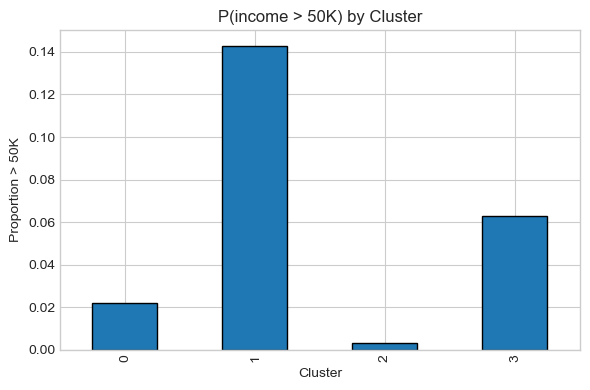

In [193]:
cluster_income.plot(kind="bar", figsize=(6,4), edgecolor="black")
plt.title("P(income > 50K) by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Proportion > 50K")
plt.tight_layout()
plt.show()


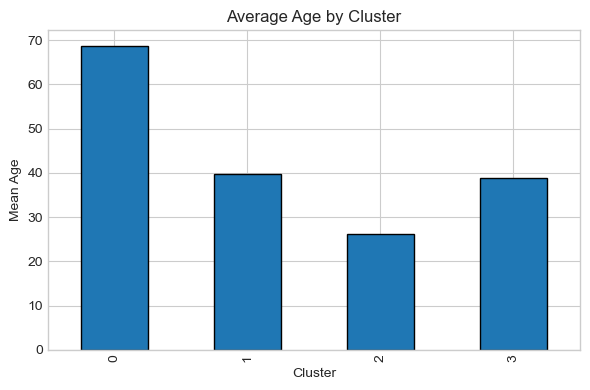

In [194]:
adult_df.groupby("cluster")["age"].mean().plot(kind="bar", figsize=(6,4), edgecolor="black")
plt.title("Average Age by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Mean Age")
plt.tight_layout()
plt.show()

## Conclusion (Also added in the Client Report):

This analysis demonstrates that structured demographic and employment data can be operationalized to support income-based risk decisioning at JPMorgan Chase. From a risk perspective, the core finding is that income tier is highly predictable. XGBoost achieved an AUC of 94.1%, with Logistic Regression and Random Forest at 92.6% and 93.6% respectively. Education level, occupation type, and weeks worked in year emerged as the dominant risk signals, consistent across both weighted EDA and model feature importance rankings. This means the risk team can rely on a small, interpretable set of observable attributes to estimate a customer's income capacity without requiring self-reported income, which is often unreliable or unavailable at the point of application.

The customer segmentation model reinforces these findings by surfacing four structurally distinct risk profiles. Retired seniors (Cluster 0, age ~69, 2.2% probability of >$50K income) and young non-working adults (Cluster 2, age ~26, 0.3%) represent the lowest income-earning capacity in the portfolio. These segments carry elevated exposure risk for credit products with income-dependent repayment. Mid-career professionals in specialty occupations (Cluster 1, age ~40, 14.3%) represent the most creditworthy segment, with full-year employment and occupational stability signalling lower default risk. Working-class adults in administrative roles (Cluster 3, age ~38, 6.3%) sit in the middle. Employed full-year but with a lower income ceiling, warranting more conservative credit limits and closer monitoring of debt-to-income ratios.

For the risk team, the immediate applications are threefold, first, the predictive model can serve as an income proxy layer in credit underwriting pipelines, flagging applicants where income capacity is uncertain. Second, the segmentation framework provides a basis for risk-adjusted product eligibility thresholds, ensuring that lending exposure is calibrated to each segment's income stability. Third, the segment-level income probabilities can inform stress testing assumptions, where Clusters 0 and 2 should be modelled with higher income shock sensitivity than Cluster 1. This work is a deployable analytical foundation and should be extended by incorporating bureau data, delinquency history, and product utilization signals to move toward a complete risk-adjusted customer view.

                                                                 **END OF FILE**